Python example using a neural network (MLPClassifier) from scikit-learn to perform a binary classification task.

#### Overall Purpose
**This program:**
- Creates a simple 2D dataset with two classes (0 and 1).
- Trains a neural network classifier (MLPClassifier) to distinguish between them.
- Evaluates the model’s performance.
- Visualizes the decision boundary that the neural network has learned.

In [10]:
import numpy as np  # for numerical and matrix operations
import pandas as pd  # for handling data (though not used here)
import matplotlib.pyplot as plt  # for plotting and visualization
from matplotlib.colors import Normalize, ListedColormap  # for controlling color scales
from sklearn.neural_network import MLPClassifier  # Multilayer Perceptron neural network


In [11]:
X = np.array([[-1, -1], [-2, -1], [-3, -2],
              [1, 1], [2, 1], [3, 2]])
y = np.array([0, 0, 0, 1, 1, 1])

- X contains 6 points in 2D space (two features).
- y contains their class labels:

- Points with negative coordinates belong to class 0
- Points with positive coordinates belong to class 1.

In [16]:
mlp = MLPClassifier(hidden_layer_sizes=(99,7,62,29,42),
                    activation="relu", random_state=42, max_iter=2000) # logistic
mlp.fit(X, y)

MLPClassifier(hidden_layer_sizes=(99, 7, 62, 29, 42), max_iter=2000,
              random_state=42)

In [17]:
test_point = np.array([[-1, 2]])
print('Prediction:', mlp.predict(test_point))

Prediction: [1]


In [18]:
print('Our Accuracy is %.2f' % mlp.score(X, y))
print('Number of mislabeled points out of a total %d points : %d'
      % (X.shape[0], (y != mlp.predict(X)).sum()))

Our Accuracy is 1.00
Number of mislabeled points out of a total 6 points : 0


Text(0, 0.5, 'X2')

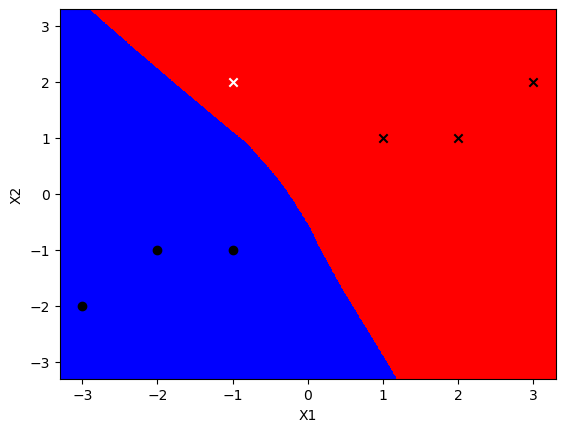

In [19]:
fig1, ax1 = plt.subplots()
#(a) Create a grid of points
#This creates a dense grid of x–y coordinates for plotting.
#The model will predict the class of every point in this grid to draw the classification regions.

xx, yy = np.meshgrid(np.arange(-3.3, 3.31, 0.01),
                     np.arange(-3.3, 3.31, 0.01))

#(b) Predict the class for each grid point
#np.column_stack creates pairs (x, y) for all grid points.
#mlp.predict() predicts class (0 or 1) for each.
#Results are reshaped to the same grid shape to enable contour plotting.

Z = mlp.predict(np.column_stack([xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

#(c) Set colors and markers
nm = Normalize(vmin = 0, vmax = 1)
cm_bright = ListedColormap(["blue", "red"])
m = ['o', 'x']

#(d) Plot the decision boundary and points
#Fills the background according to predicted class (decision regions).
ax1.contourf(xx, yy, Z, cmap = cm_bright, norm = nm)

#Plots the training points using black markers.
for i in range(len(X)):
    ax1.scatter(X[i,0], X[i,1],
                marker = m[mlp.predict(X)[i]],
                color = 'black')

#Plots the test point as a white marker with the symbol corresponding to its predicted class.
ax1.scatter(test_point[:,0], test_point[:,1],
            marker = m[mlp.predict(test_point)[0]],
            color = 'white')

#(e) Label axes and save
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')